# Evaluating Agentic Applications for Banking Chatbot: Leveraging LangGraph and IBM watsonx.governance

This notebook demonstrates a banking use case with the advanced evaluation capabilities of IBM watsonx.governance for monitoring and governing production-grade LangGraph agentic systems. It leverages existing out-of-the-box tools from the catalog, creates custom tools, and registers a LangGraph agent in the Governed Agentic Catalog. Using an Agentic RAG implementation that orchestrates OpenAI's `gpt-4o-mini`  through LangGraph workflows, we showcase how to apply different evaluators in a development environment.

**Banking Usecase Workflow:**

- We begin with a set of offline banking FAQs, which are ingested to create a vector db tool in `Governed Agentic Catalog` and a `VectorDB retrieval` node in LangGraph. 

- The `VectorDB retrieval` node handles incoming online banking queries and generates the context, which is evaluated using watsonx.governance evaluator to compute context relevance score. 

- Based on the context relevance score, the LLM agent intelligently routes the request.

- If the context relevance score score is high, the request is routed to the `VectorDB Answer Generation` node to generate response. Otherwise, it is routed to the `Web Search` node to fetch the context and then to `Web Answer generation` node to generate the response.

- The LangGraph workflow computes node-level faithfulness metrics on the generated responses.

- An experiment is created with multiple run's to evaluate the agent and the experiment results can be compared in the UI, enabling detailed evaluation. 

- Finally the complete agent is registered and saved in the `Governed Agentic Catalog`.

## Contents

  1. [Set up environment]()
  1. [Create custom tool using Governed Agentic Catalog]()
  1. [Set up the evaluator]()
  2. [Build LangGraph Application]()
  1. [Enable experiment tracking]()
  1. [Register AI Agent using Governed Agentic Catalog]()

## 1. Set up environment
### Install the dependencies

In [ ]:
%pip install --quiet "ibm-watsonx-gov[agentic,visualization,tools]" "langchain-chroma<=0.1.4" "langchain-openai<=0.3.0" pypdf

**Note**: If you encounter any Torch-related attribute errors while setting up the evaluator, try resolving them by running the cell below to uninstall Torch. This step is required when running in Watson Studio.

In [ ]:
%pip uninstall -y torch

In [ ]:
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

### Accept the credentials
The following code snippet ensures that specific environment variables are set without being hardcoded in the script. It does so by prompting the user for input only if the variables are not already set.

The environment variables need to be set are:

1. **OPENAI_API_KEY:** This is required for Open AI capabilities.
2. **WATSONX_PROJECT_ID:** This is required for IBM watsonx.governance capabilities.

For watsonx.governance Cloud
1. **WATSONX_APIKEY:** This is required for IBM watsonx.governance capabilities. Your Cloud API key can be generated by going to the [**Users** section of the Cloud console](https://cloud.ibm.com/iam#/users). From that page, click your name, scroll down to the **API Keys** section, and click **Create an IBM Cloud API key**. Give your key a name and click **Create**, then copy the created key and paste it below.
2. **WXG_SERVICE_INSTANCE_ID** [Optional] : Set if you have more than one watsonx.governance instance.
3. **WATSONX_REGION** [Optional]: Set if you are using IBM watsonx.governance as a service in a regional data center other than default **Dallas (us-south), in Texas US**. Supported region values are "us-south", "eu-de", "au-syd", "ca-tor", "jp-tok", "eu-gb".

For watsonx.governance OnPrem
1. **WATSONX_URL** : The CPD cluster URL.
2. **WATSONX_USERNAME** : The CPD username.
3. **WATSONX_PASSWORD** [Optional] : The CPD password.
4. **WATSONX_APIKEY** [Optional] : The CPD API key. Either WATSONX_APIKEY or WATSONX_PASSWORD is required for CPD authentication.
5. **WATSONX_VERSION** : The version of CPD.
6. **WATSONX_DISABLE_SSL** [Optional]: Set to true if you want to disable SSL.
7. **WXG_SERVICE_INSTANCE_ID** [Optional] : Set if you have more than one datamart

In [55]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")
_set_env("WATSONX_PROJECT_ID")

# For watsonx.governance Cloud
_set_env("WATSONX_APIKEY")
#_set_env("WATSONX_REGION")
#_set_env("WXG_SERVICE_INSTANCE_ID")

#uncomment the following lines for watsonx.governance on-prem
#_set_env("WATSONX_URL")
#_set_env("WATSONX_USERNAME")
#_set_env("WATSONX_VERSION")
#_set_env("WATSONX_PASSWORD") 
#_set_env("WATSONX_DISABLE_SSL")

## 2. Create custom tool using Governed Agentic Catalog
#### List OOTB Tools from catalog 

In [ ]:
from ibm_watsonx_gov.tools.utils.display_utils import display_tools

display_tools()

### Create custom tool to set up the local vector store

We have created a local vector store comprising of a few banking faq's. These posts focus on the various categories in banking sector such as personal banking, credit card and home loans. Hence, our queries will focus on these capabilities covered in the below posts. 

#### Define the tool code
 
Loads bank_faq.pdf, converts it to LangChain documents, creates embeddings, and initializes the chroma store as part of the custom tool code.

In [57]:
tool_name = "vector_db_store"
tool_description = "create chroma db  store for the given input pdf file"

tool_code = """
def create_vector_db_store(
    file_location: str):

    from langchain_community.document_loaders import PyPDFLoader
    from langchain.text_splitter import RecursiveCharacterTextSplitter
    from langchain.vectorstores import Chroma
    from langchain_openai import OpenAIEmbeddings
    import logging
    
    logging.getLogger("pdfminer").setLevel(logging.ERROR)
    # Step 1: Load PDF
   
    loader = PyPDFLoader(file_location)
    pages = loader.load()
    
    # Step 2: Split into chunks
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,
        chunk_overlap=50
    )
    documents = splitter.split_documents(pages)

    # Step 3: Choose embedding model
    embeddings = OpenAIEmbeddings(model="text-embedding-ada-002")
    
    # Step 4:create Chroma DB and Store
    vector_store = Chroma.from_documents(documents, embedding=embeddings)
    
    return vector_store
"""

tool_schema = {
    "title": "vector_db_store_schema",
    "type": "object",
    "properties": {
        "file_location": {"type": "string", "description": "pdf file of the test data"}
    },
    "required": ["file_location"]
}

####  Register Custom Tool

In [58]:
from ibm_watsonx_gov.tools.clients.ai_tool_client import ToolRegistrationPayload, register_tool, get_tool_info, delete_tool_with_name
from ibm_watsonx_gov.tools.utils.constants import Categories

def get_tool_payload() -> dict:
    tool_payload = {
        "tool_name": tool_name,
        "description": tool_description, 
        "code": {
            "source_code_base64": tool_code,
            "run_time_details": {
              "engine": "python 3.11"
            }
          },
         "schema": tool_schema,
         "category": [ Categories.SEARCH ]
    }    
    return tool_payload

def lookup_and_register_tool():
    try:
        # check if the tool exists
        tool_response = get_tool_info(tool_name=tool_name)
    except Exception:
         # otherwise create the tool
        tool_payload = get_tool_payload()
        tool_response = register_tool(ToolRegistrationPayload(**tool_payload))

    return tool_response

#delete_tool_with_name(tool_name)
tool_response = lookup_and_register_tool()

tool_name = tool_response["entity"]["tool_name"]
tool_name

'vector_db_store'

### Invoke the custom tool to get the vector store
For user's convenience, the vector store has been compressed. The following cell downloads the FAQs file, extracts it locally, and initializes the Chroma store.

In [59]:
from ibm_watsonx_gov.tools import load_tool
import os
import urllib.request

bank_faq_file="bank_faqs.pdf"
if os.path.exists(bank_faq_file):
    os.remove(bank_faq_file)

# Download the file
url = "https://raw.githubusercontent.com/IBM/ibm-watsonx-gov/samples/notebooks/data/agentic/bank_faqs.pdf"
urllib.request.urlretrieve(url, bank_faq_file)

vector_db_tool = load_tool(tool_name=tool_name)
vector_store = vector_db_tool.invoke({"file_location":bank_faq_file})
vector_store


## 3. Set up the evaluator

For evaluating your Agentic AI applications, you need to first instantiate the `AgenticEvaluator` class. This class defines a few evaluators to compute the different metrics. You can check the supported metrics [here](https://ibm.github.io/ibm-watsonx-gov/generated_apidoc/ibm_watsonx_gov.metrics.html)

We are going to use the following evaluators as decorators in this notebook:
1. `evaluate_context_relevance`: To compute context relevance metric of your content retrieval tool.
2. `evaluate_faithfulness`: To compute faithfulness metric of your answer generation tool. This metric does not require ground truth.

We are also going to use the following evaluators as agent level metrics in this notebook:
1. `AnswerRelevanceMetric`: To compute Answer Relevance for the agent reponse for the user query
2. `MetricGroup.CONTENT_SAFETY`: To compute the content safety metrics used to detect the harmful content in the user query.

#### Configuring Evaluations

Users can define evaluation configurations using `AgenticAIConfiguration` instance by specifying relevant fields for different evaluation types, such as context relevance and faithfulness. 

In [60]:
from ibm_watsonx_gov.config import AgenticAIConfiguration
from ibm_watsonx_gov.config.agentic_ai_configuration import \
    TracingConfiguration
from ibm_watsonx_gov.evaluators.agentic_evaluator import AgenticEvaluator
from ibm_watsonx_gov.entities.agentic_app import (AgenticApp, MetricsConfiguration)
from ibm_watsonx_gov.metrics import AnswerRelevanceMetric
from ibm_watsonx_gov.entities.enums import MetricGroup

# Define the metrics to be computed at the agentic app(interaction) level.
agentic_app = AgenticApp(name="Rag agent",
                         metrics_configuration=MetricsConfiguration(metrics=[AnswerRelevanceMetric()],
                                                                    metric_groups=[MetricGroup.CONTENT_SAFETY]))
evaluator = AgenticEvaluator(agentic_app=agentic_app,
                             tracing_configuration=TracingConfiguration(project_id=os.getenv("WATSONX_PROJECT_ID")))


## 4. Build LangGraph Application

#### Set up the State

In [61]:
from typing_extensions import TypedDict

class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        input_text (str): 
            The user's raw input query or question.            
        local_context (List[str]): 
            Context retrieved from local knowledge base or vector store. 
        web_context (List[str]): 
            Context fetched from google searches (if used). 
        generated_text (Optional[str]): 
            The final output generated by the LLM after processing all contexts.
    """
    input_text: str #The user's raw input query or question
    record_id: str #Unique identifier for the record
    local_context: list[str] #Context retrieved from vector store
    web_context: list[str] #Context fetched from web searches (if used)
    generated_text: str #The final output generated by the LLM after processing all contexts

In [62]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langgraph.config import RunnableConfig

#### Define VectorDB Retrieval Node

We are using a Similarity with Threshold Retrieval strategy. This will fetch the top 3 documents matching the query if the threshold score is more than 0.1

The `bank_vector_search_node` tool defined below is decorated with IBM watsonx.governance evaluator `evaluate_context_relevance` tool to compute the context relevance metric. This node reads the user query from the `input_text` attribute from the application state and writes the result into the `local_context` attribute back to the application state.

In [63]:
retrieval_quality_config_local_search_node = {
    "input_fields": ["input_text"],
    "context_fields": ["local_context"],
}

@evaluator.evaluate_context_relevance(configuration=AgenticAIConfiguration(**retrieval_quality_config_local_search_node))
def bank_vector_search_node(state: GraphState, config: RunnableConfig) -> dict:
    similarity_threshold_retriever = vector_store.as_retriever(search_type="similarity_score_threshold",
                                                               search_kwargs={"k": 3,
                                                                              "score_threshold": 0.1})
    context = similarity_threshold_retriever.invoke(state["input_text"])
    context_doc = [doc.page_content for doc in context]
    return {
        "local_context": context_doc
    }

### Define web search node
The `bank_web_search_node` tool defined below is decorated with IBM watsonx.governance evaluator `evaluate_context_relevance` tool to compute the context relevance metric. This node reads the user query from the `input_text` attribute from the application state and writes the result into the `web_context` attribute back to the application state.


We are using a google search OOTB tool from Governed Agentic Catalog to do the web search: google search, an out-of-the-box (OOTB) tool, loads the tool from the Governed Catalog, which the bank_web_search_node can invoke during execution


In [64]:
retrieval_quality_config_web_search_node = {
   "input_fields": ["input_text"],
    "context_fields": ["web_context"]
}

@evaluator.evaluate_context_relevance(configuration=AgenticAIConfiguration(**retrieval_quality_config_web_search_node))
def bank_web_search_node(state: GraphState, max_results: int = 5) -> dict:
    """Perform web search and return relevant content snippets"""

    from ibm_watsonx_gov.tools import load_tool
    # google search tool is an OOTB tool which preloads into the user's default inventory
    google_search_tool = load_tool(tool_name="google_search_tool")
    results = google_search_tool.invoke({"query":state["input_text"]})
    return {
        "web_context": results
    }



### Create a prompt template to get the response from the LLM

We are using `gpt-4o-mini` to generate an answer for our query.

In [65]:
def generate_response(input_text: str,  context_text: list[str]): 
    
    generate_prompt = ChatPromptTemplate.from_template(
        "Answer the query using only the provided context:\n"
        "Context: {context}\n"
        "Question: {input_text}\n"
        "Answer:"
    )
    formatted_prompt = generate_prompt.invoke(
        {"input_text": input_text, "context": "\n".join(context_text)})
    llm = ChatOpenAI(model="gpt-4o-mini")
    result = llm.invoke(formatted_prompt)
    
    return result

### Define VectorDB based answer generation tool


The `generate_bank_vector_context_node` defined below is decorated with two evaluators `evaluate_faithfulness`  for computing answer quality metrics. Like in the previous cell, this node reads the user query from the `input_text` attribute from the application state, the `context` attribute consists of the context chunks. After generating the answer, the node writes the result into the `generated_text` attribute back to the application state.

In [66]:
answer_quality_config_local_context_node = {
    "input_fields": ["input_text"],
    "context_fields": ["local_context"],
    "output_fields": ["generated_text"]
}

@evaluator.evaluate_faithfulness(configuration=AgenticAIConfiguration(**answer_quality_config_local_context_node))
def generate_bank_vector_context_node(state: GraphState, config: RunnableConfig) -> dict:
    
    result = generate_response(state["input_text"], state["local_context"])
    return {
        "generated_text": result.content
    }


### Define web search based answer generation tool

The `generate_bank_web_context_node` defined below is decorated with two evaluators `evaluate_faithfulness`  for computing answer quality metrics. Like in the previous cell, this node reads the user query from the `input_text` attribute from the application state, the `context` attribute consists of the context chunks. After generating the answer, the node writes the result into the `generated_text` attribute back to the application state.

In [67]:
answer_quality_config_local_context_node = {
    "input_fields": ["input_text"],
    "context_fields": ["web_context"],
    "output_fields": ["generated_text"]
}

@evaluator.evaluate_faithfulness(configuration=AgenticAIConfiguration(**answer_quality_config_local_context_node))
def generate_bank_web_context_node(state: GraphState, config: RunnableConfig) -> dict:
   
    result = generate_response(state["input_text"], state["web_context"])
    return {
        "generated_text": result.content
    }


#### Adding a Router Function to Check Context Relevance

- The `check_context_relevance` function evaluates the retrieved context and assigns a **Context Relevance Score**.  
- If the score meets the required threshold, the workflow proceeds to the **Bank VectorDB Answer Generation** node.  
- If the score is below the threshold, the workflow reroutes to the **Bank Web Answer Generation** for additional information.  

In [68]:
def check_context_relevance(state: GraphState) -> str:

   
    latest_metric = evaluator.get_metric_result(
        metric_name="context_relevance", node_name="bank_vector_search_node")

    if not latest_metric:
        # Default to "no" if no metrics found
        return "Context Relevance Score is Bad"
    
    # Check if context relevance is below threshold
    if latest_metric.value > 0.5:
        return "Context Relevance Score is Good"
    else:
        return "Context Relevance Score is Bad"
        
   

#### Assemble your application

In [69]:
from langgraph.graph import START, END, StateGraph

def build_llm_agent(): 
    
    graph = StateGraph(GraphState)
    
    # Add nodes
    graph.add_node("Bank VectorDB Retrieval", bank_vector_search_node)
    graph.add_node("Bank Web Search", bank_web_search_node)
    graph.add_node("Bank VectorDB Answer Generation", generate_bank_vector_context_node)
    graph.add_node("Bank Web Answer Generation", generate_bank_web_context_node)
    
    # Add edges
    graph.add_edge(START, "Bank VectorDB Retrieval")
    graph.add_conditional_edges(
        "Bank VectorDB Retrieval",
        check_context_relevance,
        {
            "Context Relevance Score is Good": "Bank VectorDB Answer Generation",
            "Context Relevance Score is Bad": "Bank Web Search",
        },
    )
    graph.add_edge("Bank Web Search", "Bank Web Answer Generation")
    graph.add_edge("Bank VectorDB Answer Generation", END)
    graph.add_edge("Bank Web Answer Generation", END)
    
    # Compile the graph
    banking_app = graph.compile()
    
    return banking_app

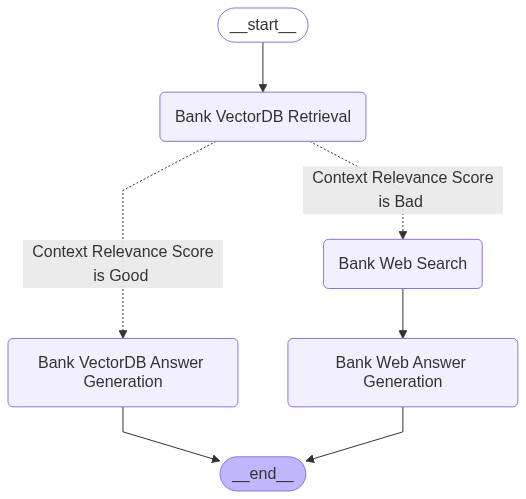

In [70]:
agentic_bank_app = build_llm_agent()
agentic_bank_app

## 5. Enable Experiment Tracking

In [71]:
ai_experiment_id = evaluator.track_experiment(
    name="Banking ChatBot Quality Experiment",
    use_existing=True
)

Using existing AI experiment with id 74c0da46-4585-4997-979c-215047289265.



### Start the Experiment Run 1

Now the application is invoked for two row's of data with the `input_text` which is the user's raw input query or question. 

In [ ]:
from ibm_watsonx_gov.entities.ai_experiment import AIExperimentRunRequest
name="run-1"
# [OPTIONAL] Specify custom tags for the experiment run
custom_tags = []
'''
custom_tags = [
    {
        "key": "LLM",
        "value": "gpt-4o-mini"
    },
    {
        "key": "temperature",
        "value": 0.4
    }
]
'''
run_request = AIExperimentRunRequest(name=name, custom_tags=custom_tags)
evaluator.start_run(run_request)

agentic_bank_app.invoke({"input_text": "How do I open a savings account"
                        })
agentic_bank_app.invoke({"input_text": "What is the minimum balance required to maintain a savings account"
                        })


#### [OPTIONAL] Log custom metrics
If there are any custom metrics which are computed outside watsonx.gov, users can log them to the run result.

In [ ]:
# Update the custom metrics result if you want to log any custom metrics.
custom_metrics_result = []
'''
custom_metrics_result = [
    {
        "name": "metric_A",
        "value": 12.713594
    },
    {
        "name": "metric_B",
        "value": 0.57656,
        "thresholds": [
            {
                "type": "lower_limit",
                "value": 0.7
            }
        ]
    },
    {
        "name": "metric_C",
        "value": 4.297817,
        "node_name": "Bank Web Answer Generation",
        "applies_to": "node"
    },
    {
        "name": "metric_D",
        "value": 2.613211,
        "applies_to": "node",
        "node_name": "Bank VectorDB Answer Generation"
    }
]

# Log the custom metrics result
evaluator.log_custom_metrics(custom_metrics_result)
'''

In [ ]:
# End the experiment run
evaluator.end_run()

### Prepare the App results and Display the metrics

By default, the metric result will only include the `interaction_id` column.  
If you want to include additional data like input, output or ground_truth, you can specify them in the `input_data` parameter.

In [ ]:
from IPython.display import display

run_result = evaluator.get_result()
display(run_result.to_df())

### Start the Experiment Run 2

Now the application is invoked to evaluate the second run of the experiment.

In [ ]:
name="run-2"
# [OPTIONAL] Specify custom tags for the experiment run
custom_tags = []
'''
custom_tags = [
    {
        "key": "LLM",
        "value": "Granite 20B"
    },
    {
        "key": "temperature",
        "value": 0.5
    }
]
'''
run_request = AIExperimentRunRequest(name=name, custom_tags=custom_tags)
evaluator.start_run(run_request)
agentic_bank_app.invoke({"input_text": "How do I open a savings account?"
                        })
agentic_bank_app.invoke({"input_text": "How can I convert my purchases into EMIs?"
                        })

In [ ]:
# [OPTIONAL] Log the custom metrics, if any
custom_metrics_result = []
'''
custom_metrics_result = [
    {
        "name": "metric_A",
        "value": 10.2432
    },
    {
        "name": "metric_B",
        "value": 0.68116,
        "thresholds": [
            {
                "type": "lower_limit",
                "value": 0.7
            }
        ]
    },
    {
        "name": "metric_C",
        "value": 3.6837,
        "node_name": "Bank Web Answer Generation",
        "applies_to": "node"
    },
    {
        "name": "metric_D",
        "value": 2.3243,
        "applies_to": "node",
        "node_name": "Bank VectorDB Answer Generation"
    }
]

# Log the custom metrics result
evaluator.log_custom_metrics(custom_metrics_result)
'''

In [ ]:
# End the experiment run
evaluator.end_run()

### Compare the AI experiment runs in Evaluation Studio UI

You can use Evaluation Studio UI to view the comparison of AI experiment runs with below URL. 

In [78]:
from ibm_watsonx_gov.entities.ai_experiment import AIExperiment

ai_experiment = AIExperiment(
    asset_id = ai_experiment_id
)

evaluator.compare_ai_experiments(
    ai_experiments = [ai_experiment]
)

Retrieved AI experiment asset 74c0da46-4585-4997-979c-215047289265.

Created AI Evaluation asset with id f282152a-d35d-42e8-ac2c-2b959b935c3b.
AI Evaluation can be viewed in Evaluation Studio UI at URL: https://dataplatform.cloud.ibm.com/aiopenscale/studioPage?container_type=project&container_id=216b27a3-61ed-4095-922b-6d318a7c5150&asset_id=f282152a-d35d-42e8-ac2c-2b959b935c3b&tearsheet_mode=true



'https://dataplatform.cloud.ibm.com/aiopenscale/studioPage?container_type=project&container_id=216b27a3-61ed-4095-922b-6d318a7c5150&asset_id=f282152a-d35d-42e8-ac2c-2b959b935c3b&tearsheet_mode=true'

## 6. Register AI Agent 

### Capture the agent code

Capture the agent code to save it in the governed agentic catalog. 

In [79]:
from ibm_watsonx_gov.agent_catalog.utils.notebook_utils import get_all_code_from_notebook

#Uncomment the following line to install nbformat if you are running the notebook from Visual Studio.
#%pip install nbformat

file_name = "LangGraph agent using governed catalog and experiment tracking.ipynb"

#To access the current notebook as a project asset in Watsonx Studio, uncomment the following lines when running in a Cloud environment:
#from ibm_watson_studio_lib import access_project_or_space
#wslib = access_project_or_space({'token':<project token>})
#path = wslib.assets.list_attachments(<name of your current notebook>, asset_type='notebook', raw=True)[0]['object_key']
#assets = wslib.storage.download_file(path, local_filename=file_name)

#To access the current notebook as a project asset in Watsonx Studio, uncomment the following lines when running in a CPD environment: 
#from ibm_watson_studio_lib import access_project_or_space
#import requests
#wslib = access_project_or_space()
#attachment_id = wslib.assets.list_attachments("LangGraph agent using governed catalog", asset_type='notebook', raw=True)[0]['object_key']
#project_asset_url = os.getenv("WATSONX_URL") + f"/v2/asset_files/{attachment_id}?project_id=" + os.getenv("WATSONX_PROJECT_ID")
#token = wslib.auth.get_current_token()
#headers = {
#        "Authorization": f"Bearer {token}",
#        "Content-Type": "application/json"
#    }
#response = requests.get(project_asset_url, headers=headers, verify=False)
#with open(file_name, "wb") as f:
#    f.write(response.content)

main_method_name = "build_llm_agent"
agent_code = get_all_code_from_notebook(file_name, main_method_name)

#### Construct payload to register the agent
Register the agent with basic details such as name, description, code, type, and framework. The agent will be saved in the Governed Agentic Catalog.

In [81]:
agent_schema = {
    "title": "agent_input",
    "type": "object",
    "properties": {
        "input_text": {
            "type": "string",
            "description": "The message text from the user"
        },
        "record_id": {
            "type": "string",
            "description": "unique record id"
        }
    },
    "required": [
        "input_text"
    ]
}

In [82]:
agent_config = {
    "display_name": "Banking usecase agent",
    "agent_name": "Banking_usecase_agent",
    "description": "This agent is used to get the information on the banking queries",
    "framework": ["langgraph"],
    "service_provider_type": "custom",
    "schema": agent_schema,
    "code": {
        "source_code": agent_code,
        "run_time_details":{
            "engine": "python 3.11"
        }
    },
    "agent_type":"code"    
}

In [ ]:
from ibm_watsonx_gov.agent_catalog.clients.ai_agent_client import register_agent, delete_agent_with_name

#delete_agent_with_name(agent_config["agent_name"])
agent_resp = register_agent(payload=agent_config)
agent_id = agent_resp["metadata"]["id"]
agent_name = agent_resp["entity"]["agent_name"]
agent_name

### Load and Invoke Agent

Loads the agent metadata from the catalog using the agent name and invokes the code logic with user inputs to return the response

In [84]:
from ibm_watsonx_gov.agent_catalog.core.agent_loader import get_agent_input_data_from_schema

input_data_schema = get_agent_input_data_from_schema(agent_schema)
input_data_schema

{'input_text': '<string value>', 'record_id': '<string value>'}

In [ ]:
from ibm_watsonx_gov.agent_catalog.core.agent_loader import load_agent
import json

agent = load_agent(agent_name=agent_name)

response = agent.invoke({"input_text": "How can I convert my purchases into EMIs"})
response["result"]["generated_text"]

In [86]:
from IPython.display import Markdown, display
from ibm_watsonx_gov.tools.utils.environment import get_base_url

platform_url = get_base_url().replace("api.", "") + "/aigov/modelinventory/ai-tools?context=wx"
display_text = f"Your agent is now registered in the Governed Agentic Catalog. You can view it through the [Governed Agentic Catalog UI]({platform_url}) to access details, compare it with other agents, and perform additional actions."

display(Markdown(display_text))

Your agent is now registered in the Governed Agentic Catalog. You can view it through the [Governed Agentic Catalog UI](https://dataplatform.cloud.ibm.com/aigov/modelinventory/ai-tools?context=wx) to access details, compare it with other agents, and perform additional actions.

Author: [Swapna Somineni](swapna.somineni@in.ibm.com)
